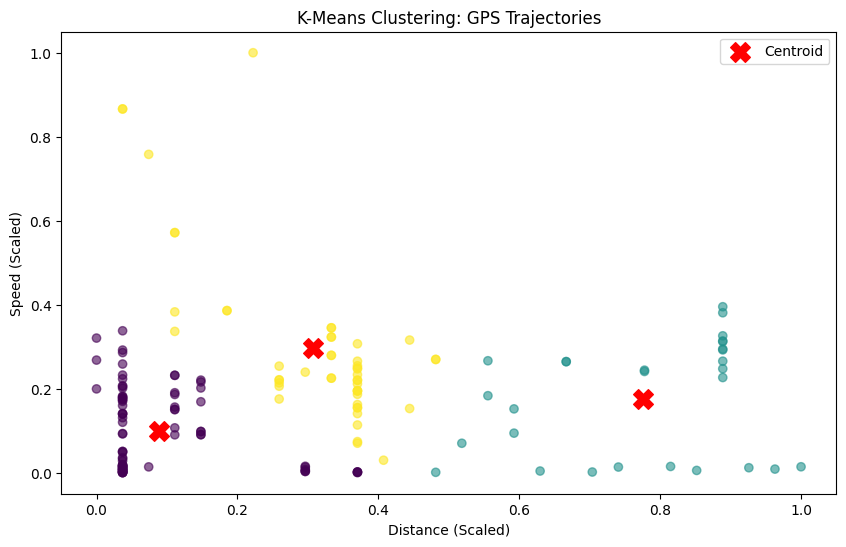

   id_android  distance      speed  kluster
0           0     2.652  19.210586        0
1           0     5.290  30.848229        0
2           1     0.918  13.560101        0
3           1     7.700  19.766679        0
4           0     3.995  25.807401        0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

baca = pd.read_csv("go_track_tracks.csv")
baca = baca.drop(["linha"], axis=1)
baca_x = baca.iloc[:, 1:3]
x_array = np.array(baca_x)

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_array)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(x_scaled)


baca["kluster"] = kmeans.labels_


plt.figure(figsize=(10,6))
scatter = plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=baca['kluster'], cmap='viridis', alpha=0.6)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroid')

plt.xlabel('Distance (Scaled)')
plt.ylabel('Speed (Scaled)')
plt.title('K-Means Clustering: GPS Trajectories')
plt.legend()
plt.show()

print(baca[['id_android', 'distance', 'speed', 'kluster']].head())